# Plan your trip

In [ ]:
import os
import sys
from dotenv import load_dotenv
import time
import pandas as pd
from warnings import filterwarnings
filterwarnings("ignore")
from IPython.display import Image

# Local application
import scripts.geocodage_villes
from scripts.meteo import meteo_villes
from scripts.scrape_hotels import scrape_booking
from scripts.fusion_chargement_s3 import generer_dataset_final, upload_dataset_final_s3
from scripts.rds_sql import base_sql
from scripts.cartes import visualiser_cartes_dataset_final
os.makedirs("data", exist_ok=True)

## 1 - Géocodage des villes

In [ ]:
# Exécution du script geocode_ville.py
%run scripts/geocodage_villes.py

# Visualiser les données géocodées
df_geo = pd.read_csv("data/geocode_villes.csv")
display(df_geo.head())
print(f"{len(df_geo)} villes géocodées.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\geocode_villes.csv


,id_ville,ville,latitude,longitude
0,fb1372c111d5,Mont Saint Michel,48.635954,-1.511460
1,b1926dc4d399,Saint Malo,48.649518,-2.026041
2,5fd0187b51b2,Bayeux,49.276462,-0.702474
3,4e9b8cad09f6,Le Havre,49.493898,0.107973
4,e76e9773c33d,Rouen,49.440459,1.093966


35 villes géocodées.


## 2 - Données météo

In [ ]:
# Exécution du script complet meteo.py
%run scripts/meteo.py

df_meteo = pd.read_csv("data/villes_meteo.csv")
display(df_meteo.head())
print(f"Données météo récupérées pour {len(df_meteo)} villes.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\villes_meteo.csv


,id_ville,nom_ville,temp_moy,ressenti,humidity_moy,prob_pluie_moy,uv_moy,meteo_score
27,4cc9af0bda9a,Collioure,16.7,15.8,52.1,0.0,1.1,59.3
24,17b7723e85eb,Nimes,13.6,12.6,60.3,0.0,1.4,52.4
22,a76b712fa6fd,Avignon,12.9,12.0,60.0,0.0,1.4,51.4
18,e5fcdbaf84c4,Bormes les Mimosas,13.0,12.0,64.3,0.0,1.5,50.8
23,975923312ee1,Uzes,13.2,12.1,62.4,0.0,1.3,50.3


## 3 - Hotels

In [ ]:
# Exécution du script complet scrape_hotels.py
%run scripts/meteo.py

df_hotels = pd.read_csv("data/hotels.csv")
display(df_hotels.head(10))
print(f"{len(df_hotels)} hôtels récupérés.")

,id,id_ville,ville,nom,url,note,latitude,longitude
0,31a09c0f-8f39-4cce-95b6-33583061d3d7,fb1372c111d5,Mont Saint Michel,Hôtel Vert,https://www.booking.com/hotel/fr/vert.fr.html?...,"Avec une note de 8,1\n8,1\nTrès bien\n6 054 ex...",48.635954,-1.511460
1,789576db-d1a8-47ff-85b4-c07efb6d3f41,fb1372c111d5,Mont Saint Michel,Les Terrasses Poulard,https://www.booking.com/hotel/fr/les-terrasses...,"Avec une note de 7,4\n7,4\nBien \n3 597 expéri...",48.635954,-1.511460
2,33fc5628-a2c9-4d54-b032-1c9734cc5c26,fb1372c111d5,Mont Saint Michel,Mercure Mont Saint Michel,https://www.booking.com/hotel/fr/mont-saint-mi...,"Avec une note de 8,3\n8,3\nTrès bien\n3 671 ex...",48.635954,-1.511460
3,4889734d-63f9-452e-8aca-011559719c8f,fb1372c111d5,Mont Saint Michel,La Mère Poulard,https://www.booking.com/hotel/fr/la-mere-poula...,"Avec une note de 7,6\n7,6\nBien \n3 378 expéri...",48.635954,-1.511460
4,d3cdff96-f547-45cd-bba4-ff60bbd429a1,fb1372c111d5,Mont Saint Michel,Le Mouton Blanc,https://www.booking.com/hotel/fr/le-mouton-bla...,"Avec une note de 7,2\n7,2\nBien \n1 899 expéri...",48.635954,-1.511460
5,9afec90d-97e7-4536-bd1d-92bbd17648b3,b1926dc4d399,Saint Malo,T2 terrasse de charme à Rochebonne 400 m plage,https://www.booking.com/hotel/fr/t2-de-charme-...,"Avec une note de 9,5\n9,5\nExceptionnel\n70 ex...",48.649518,-2.026041
6,ef98e4de-374d-4958-8a2a-acec550b4961,b1926dc4d399,Saint Malo,Les Bois Flottés,https://www.booking.com/hotel/fr/les-bois-flot...,"Avec une note de 9,1\n9,1\nFabuleux \n99 expér...",48.649518,-2.026041
7,172462d8-5b4f-494a-ad62-623dc13241cb,b1926dc4d399,Saint Malo,Kyriad Prestige Saint-Malo,https://www.booking.com/hotel/fr/kyriad-presti...,"Avec une note de 8,8\n8,8\nSuperbe\n6 221 expé...",48.649518,-2.026041
8,ea80f1ab-00b7-4c04-aae7-0e7084f5d416,b1926dc4d399,Saint Malo,Résidence Pierre & Vacances Ty Mat,https://www.booking.com/hotel/fr/maevatymat.fr...,"Avec une note de 8,1\n8,1\nTrès bien\n2 736 ex...",48.649518,-2.026041
9,33145138-4bd8-42fc-98c3-adf2d26cfd1d,b1926dc4d399,Saint Malo,Bonne rencontre,https://www.booking.com/hotel/fr/bonne-rencont...,"Avec une note de 9,6\n9,6\nExceptionnel\n9 exp...",48.649518,-2.026041


175 hôtels récupérés.


## 4 - Fusions et export s3

In [ ]:
# Exécution du script complet fusion_chargement_s3.py
%run scripts/fusion_chargement_s3.py

df_final = pd.read_csv("data/dataset_final.csv")
display(df_final.head())
print(f"Shape finale : {df_final.shape}")

Dataset final généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\dataset_final.csv
Colonnes présentes : Index(['id', 'id_ville', 'ville', 'nom', 'url', 'note', 'latitude',
       'longitude', 'nom_ville', 'temp_moy', 'ressenti', 'humidity_moy',
       'prob_pluie_moy', 'uv_moy', 'meteo_score'],
      dtype='object')
                                     id      id_ville              ville  \
0  31a09c0f-8f39-4cce-95b6-33583061d3d7  fb1372c111d5  Mont Saint Michel   
1  789576db-d1a8-47ff-85b4-c07efb6d3f41  fb1372c111d5  Mont Saint Michel   
2  33fc5628-a2c9-4d54-b032-1c9734cc5c26  fb1372c111d5  Mont Saint Michel   
3  4889734d-63f9-452e-8aca-011559719c8f  fb1372c111d5  Mont Saint Michel   
4  d3cdff96-f547-45cd-bba4-ff60bbd429a1  fb1372c111d5  Mont Saint Michel   

                         nom  \
0                 Hôtel Vert   
1      Les Terrasses Poulard   
2  Mercure Mont Saint Michel   
3            La Mère Poulard   
4            Le Mouton Bla

## 5 - Chargement SQL/RDS

In [ ]:
# Exécution du script complet rds_sql.py
%run scripts/rds_sql.py

base_sql()
print("Chargement terminé !")

Données insérées avec succès dans RDS.
Chargement terminé !


## 6 - Génération des cartes

Connecté à RDS
Connexion RDS fermée


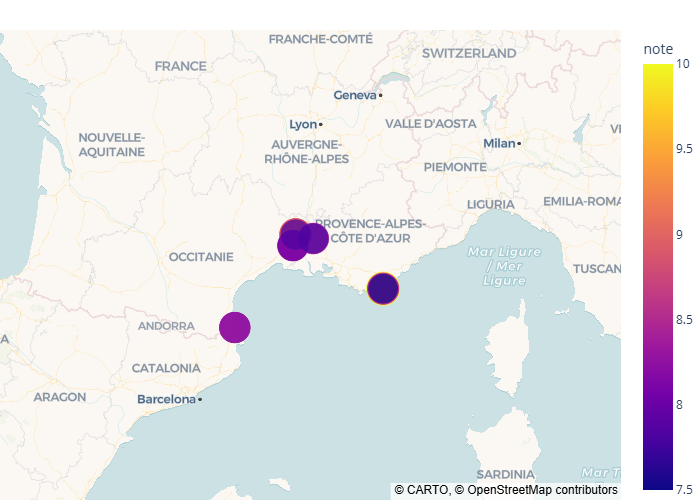

In [ ]:
# Exécution du script complet cartes.py
%run scripts/cartes.py

visualiser_cartes_dataset_final(top_villes=5, top_hotels=20, save_files=False)
# Chemin vers ton PNG
png_path_1 = "data/top_villes.png"
png_path_2 = "data/top_hotels.png"

# Affichage dans le notebook
Image(filename=png_path_1)
Image(filename=png_path_2)